In [1]:
import numpy as np
from qubicpack.qubicfp import qubicfp
import sys,os
import glob
import yaml
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab

In [2]:
day = '2023-04-18'
data_dir = '/home/qubic/Calib-TD/'+day+'/'
words = ['skydip']
keywords = ['*{}*'.format(word) for word in words]
for keyword in keywords:
    dirs = np.sort(glob.glob(data_dir+keyword))
    print(dirs)

['/home/qubic/Calib-TD/2023-04-18/2023-04-18_12.56.51__skydip1']


In [ ]:
data_path = "/home/belen/Doctorado/qubic-dev/qubic/qubic/data/Flux_jumps/"
soft_path = "/home/belen/Doctorado/qubic-dev/qubic/qubic/scripts/Calibration/Flux_jumps/"
sys.path.append(os.path.abspath(soft_path))

In [3]:
import jumps_review as jr
import utilities as utils

## 12.56.51 skydip

In [4]:
dataset0 = dirs[0]
a = qubicfp()
a.read_qubicstudio_dataset(dataset0)

ASIC1     Observation date: 2023-04-18 12:56:51.307000
ASIC1 Observation end date: 2023-04-18 14:02:19.271000
ASIC2     Observation date: 2023-04-18 12:56:51.308000
ASIC2 Observation end date: 2023-04-18 14:02:19.271000
No hornswitch data found in directory: /home/qubic/Calib-TD/hornswitch
Please give a valid asic number
No previously saved filter information: QUBIC_TES_ASIC1_20230418T125651UTC.filter.pickle
No previously saved filter information: QUBIC_TES_ASIC2_20230418T125651UTC.filter.pickle
No PPS in MMR_HK
No PPS.  Using computer time instead
TES temperature varies between 319.9mK and 320.2mK during the measurement


True

In [5]:
tod = a.tod()
timeaxis = tod[0]
todarray = tod[1]
init = timeaxis[0]
tt = timeaxis - init

print('number of timesamples along every TES in this dataset:', np.shape(todarray[0,:]))

suggest nsamples=618496 which is  2^12*151
number of timesamples along every TES in this dataset: (618496,)


In [64]:
tt[-1]/60

65.47883857488632

In [7]:
# TES_yes: idx TES with flux jumps found by haar filter
# TES_no: idx TES with no flux jumps found
# TES_yes_dt: refinament of idx TES with flux jumps using DT (could be equal to TES_yes)
# jump_data: "idx", xc", "xcf", "nc"
# dt_jump_data: "idx", "xcdt", "xcfdt", "ncdt"
# corrected data: idx and TES corrected
# offset: amplitudes of jumps

results = {
    'TES_yes': [],
    'TES_no': [],
    'TES_yes_dt': [],
    'jump_data': {},
    'dt_jump_data': {},
    'corrected_data': {},
    'offset': {}
    }

In [8]:
sat = jr.saturation() 
sat_mask, sat_idx, sat_frac, n_sat = sat.detect_saturation(todarray)

#IV class. You have to load the directory and the filename of the IV analysis
#IVdict2025.yaml or IVdict2023.yaml are the dicts with the IV information from 2025 and 2022-2023
iv = jr.badIV(directory=soft_path, n_times=10, TES_number=256, filename="IVdict2023.yaml") 
iv_mask = iv.select_badIV()

good_mask = sat_mask & iv_mask        # Create a mask with both saturation and bad IV
good_idx  = np.where(good_mask)[0]    # index of TES with good IV and no saturation
good_tod  = todarray[good_mask, :]    # TOD of good TES

print(good_idx)

[  2   3   4   5   7   8   9  10  12  14  15  18  19  21  22  24  25  26
  27  28  29  30  31  32  33  35  36  37  38  39  40  41  43  45  48  53
  54  55  56  58  59  60  61  62  63  65  66  67  68  69  70  71  72  75
  76  77  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94
  95  97  98 100 103 105 106 109 110 111 112 116 120 121 123 128 129 130
 131 132 133 134 135 136 138 139 140 141 142 144 145 146 147 148 149 150
 151 152 155 157 158 159 160 161 162 163 166 167 168 169 170 171 172 173
 175 177 178 179 180 181 182 183 184 185 186 188 192 193 194 195 196 197
 198 199 200 201 202 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 219 220 222 223 224 232 235 236 237 238 239 241 242 243 244 245 246
 247 248 254 255]


In [66]:
iv_idx = np.where(iv_mask==False)[0] 
iv_idx

array([ 16,  17,  23,  42,  44,  46,  47,  64,  73,  78,  96,  99, 101,
       113, 117, 118, 119, 122, 124, 125, 126, 127, 143, 153, 154, 156,
       165, 176, 189, 190, 191, 218, 221, 225, 226, 227, 228, 229, 230,
       249, 250, 252, 253])

In [53]:
thr = [2e5]  # Multiple thresholds for better detection
window_size = 700  # Optimized for this dataset length
fluxjumps = jr.fluxjumps(thr=thr, window_size=window_size)

In [54]:
jump_data = {}
for idx_good in good_idx:
    nc, xc, xcf, thr_used = fluxjumps.jumps_detection(
        todarray[idx_good], 
        consec=True,   # Merge consecutive jumps
        nc_cond=True  # Re-threshold if too many jumps
    )
    jump_data[idx_good] = {'nc': nc, 'xc': xc, 'xcf': xcf, 'thr_used': thr_used}

In [55]:
# Classify TES
TES_yes = [idx for idx in good_idx if jump_data[idx]['nc'] > 0]
TES_no = [idx for idx in good_idx if jump_data[idx]['nc'] == 0]

In [56]:
results['TES_yes'] = TES_yes
results['TES_no'] = TES_no
results['jump_data'] = jump_data

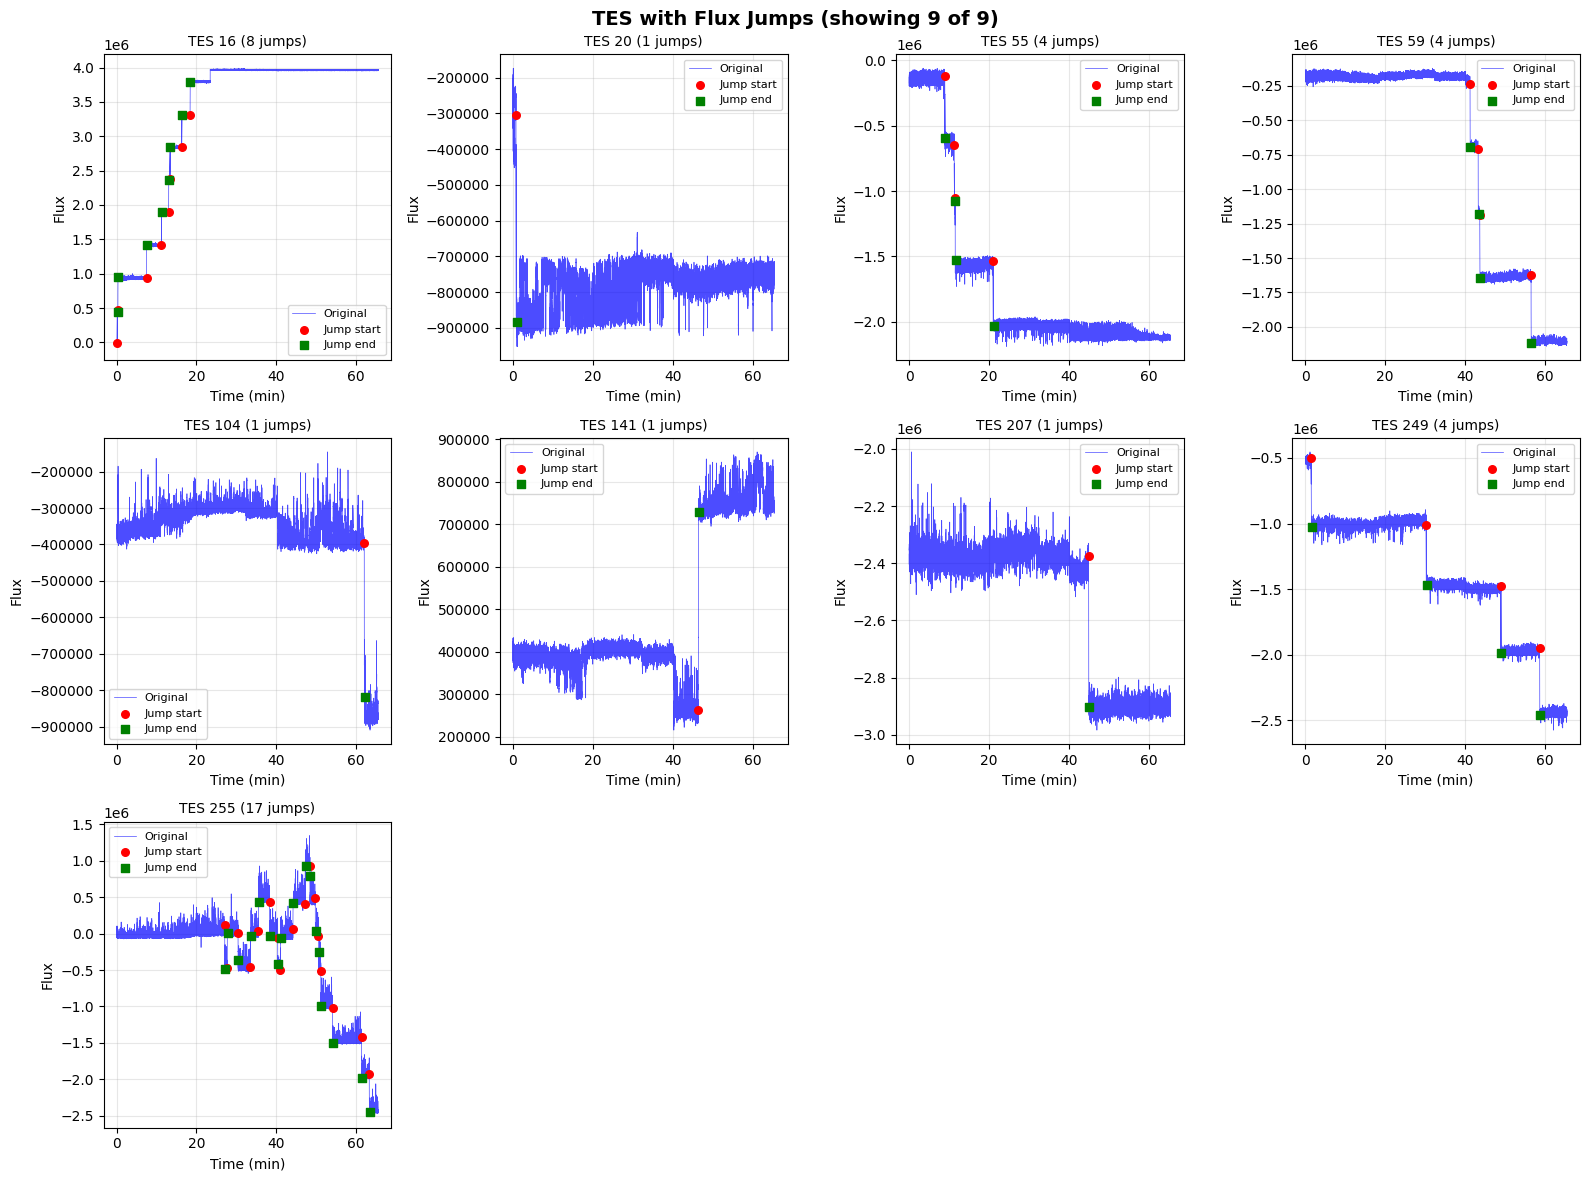

0

In [59]:
utils.plot_jump_detections(tt, todarray, results, DT=False)

In [60]:
corr = jr.correction(region_off=5, region_amp=3, change_mode="const")
corrected_tod = {}
offset = {}
for idx in TES_yes:
    if idx in jump_data:
        xc = jump_data[idx]['xc']
        xcf = jump_data[idx]['xcf']
        nc = jump_data[idx]['nc']
        if nc > 0:
            offset[idx] = corr.calculate_amplitude(todarray[idx], xc, xcf, nc)
            corrected_tod[idx] = corr.correct_TOD(todarray[idx], offset[idx], xc, xcf, nc)

In [61]:
results['corrected_data'] = corrected_tod
results['offset'] = offset

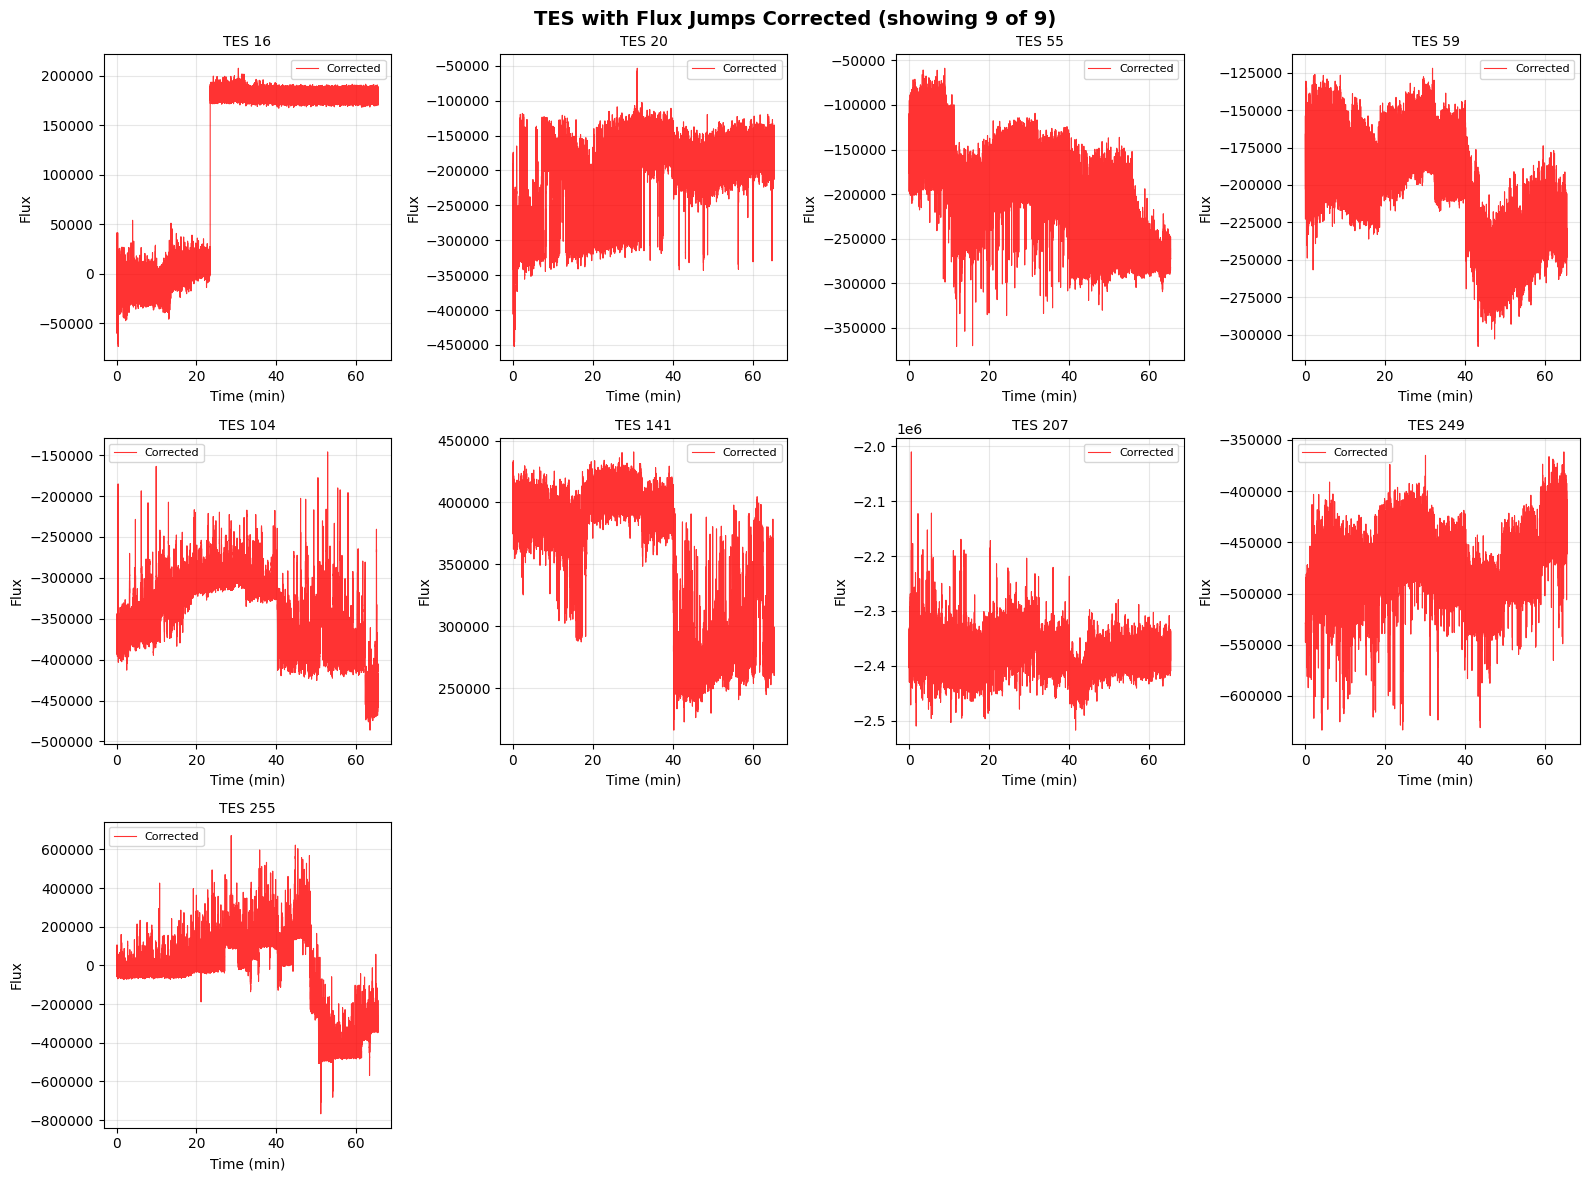

0

In [63]:
utils.plot_corrections(tt, todarray, results)

In [62]:
utils.save_results(results, output_dir=data_path + "year_23_day_1804_12.56.51", dataset_name="23_1804_12.56.51")

Saved pickle file to: ./day_1804_12.56.51/23_1804_12.56.51_results.pkl

All results saved to: ./day_1804_12.56.51
Total files saved: 1



['./day_1804_12.56.51/23_1804_12.56.51_results.pkl']